# Combined Results  

This notebook generates the combined results table and comparison graphs for Logistic Regression, Naive Bayes, SVM, and DistilBERT.


### 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path

### 2. Input All Results

In [2]:
comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Best Setting": "Class imbalance handling (C=10)",
        "Accuracy": 0.7065,
        "Macro F1": 0.5799,
        "Weighted F1": 0.6829,
        "Negative F1": 0.6545,
        "Neutral F1": 0.2308,
        "Positive F1": 0.8544,
        "Macro Precision": 0.5927,
        "Macro Recall": 0.5815,
    },
    {
        "Model": "Naive Bayes",
        "Best Setting": "alpha=0.01",
        "Accuracy": 0.7283,
        "Macro F1": 0.6057,
        "Weighted F1": 0.6967,
        "Negative F1": 0.7143,
        "Neutral F1": 0.2727,
        "Positive F1": 0.8302,
        "Macro Precision": 0.6622,
        "Macro Recall": 0.6044,
    },
    {
        "Model": "SVM",
        "Best Setting": "Class imbalance handling (C=1)",
        "Accuracy": 0.7174,
        "Macro F1": 0.6120,
        "Weighted F1": 0.7044,
        "Negative F1": 0.7018,
        "Neutral F1": 0.2857,
        "Positive F1": 0.8485,
        "Macro Precision": 0.6184,
        "Macro Recall": 0.6111,
    },
    {
        "Model": "DistilBERT",
        "Best Setting": "distilbert-base-uncased, translated English reviews",
        "Accuracy": 0.7500,
        "Macro F1": 0.6243,
        "Weighted F1": 0.7250,
        "Negative F1": 0.7500,
        "Neutral F1": 0.2500,
        "Positive F1": 0.8700,
        "Macro Precision": 0.6433,
        "Macro Recall": 0.6300,
    },
])

# Round all numeric columns to 4 decimal places
numeric_columns = comparison_df.select_dtypes(include="number").columns
comparison_df[numeric_columns] = comparison_df[numeric_columns].round(4)

display(comparison_df)


,Model,Best Setting,Accuracy,Macro F1,Weighted F1,Negative F1,Neutral F1,Positive F1,Macro Precision,Macro Recall
0,Logistic Regression,Class imbalance handling (C=10),0.7065,0.5799,0.6829,0.6545,0.2308,0.8544,0.5927,0.5815
1,Naive Bayes,alpha=0.01,0.7283,0.6057,0.6967,0.7143,0.2727,0.8302,0.6622,0.6044
2,SVM,Class imbalance handling (C=1),0.7174,0.6120,0.7044,0.7018,0.2857,0.8485,0.6184,0.6111
3,DistilBERT,"distilbert-base-uncased, translated English reviews",0.7500,0.6243,0.7250,0.7500,0.2500,0.8700,0.6433,0.6300


### 4. Graph 

To compare the key metrics of all models

In [3]:
GRAPH_DIR = Path("model_training/results")
OUTPUT_DIR = GRAPH_DIR / "comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


Saved figure to: model_training\results\comparison\overall_metrics.png


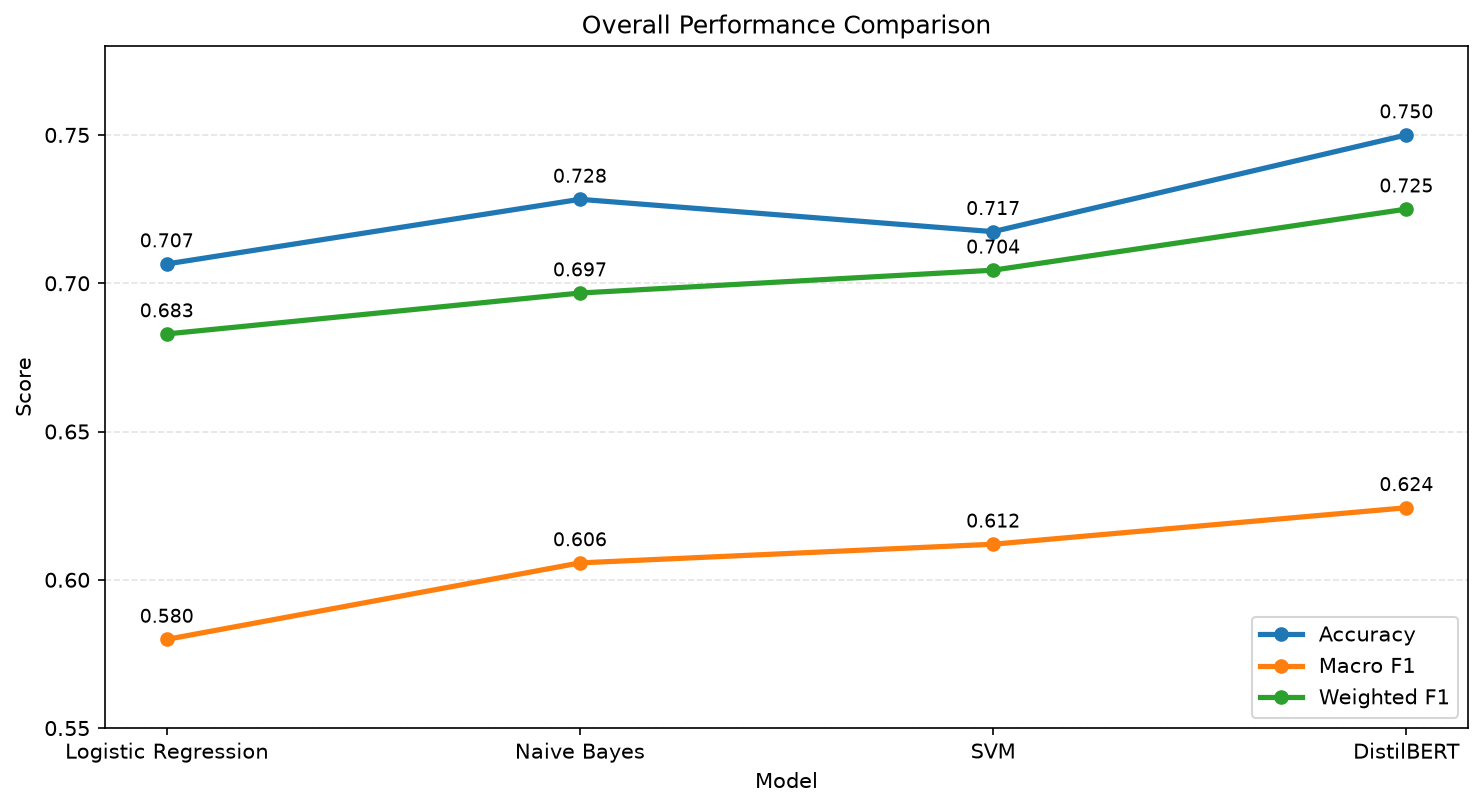

In [4]:
overall_metrics = comparison_df.set_index("Model")[
    ["Accuracy", "Macro F1", "Weighted F1"]
]

fig, ax = plt.subplots(figsize=(10, 5.5))
x = range(len(overall_metrics.index))

for metric in overall_metrics.columns:
    values = overall_metrics[metric].values
    ax.plot(x, values, marker="o", linewidth=2.5, label=metric)
    for xi, value in zip(x, values):
        ax.annotate(
            f"{value:.3f}",
            (xi, value),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9,
        )

ax.set_title("Overall Performance Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_xticks(list(x))
ax.set_xticklabels(overall_metrics.index)
ax.set_ylim(0.55, 0.78)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(loc="lower right")
plt.tight_layout()

save_path = OUTPUT_DIR / "overall_metrics.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {save_path}")


To compare the F1-scores of all models to see how each models performs on each sentiment

Saved figure to: model_training\results\comparison\F1_comparison.png


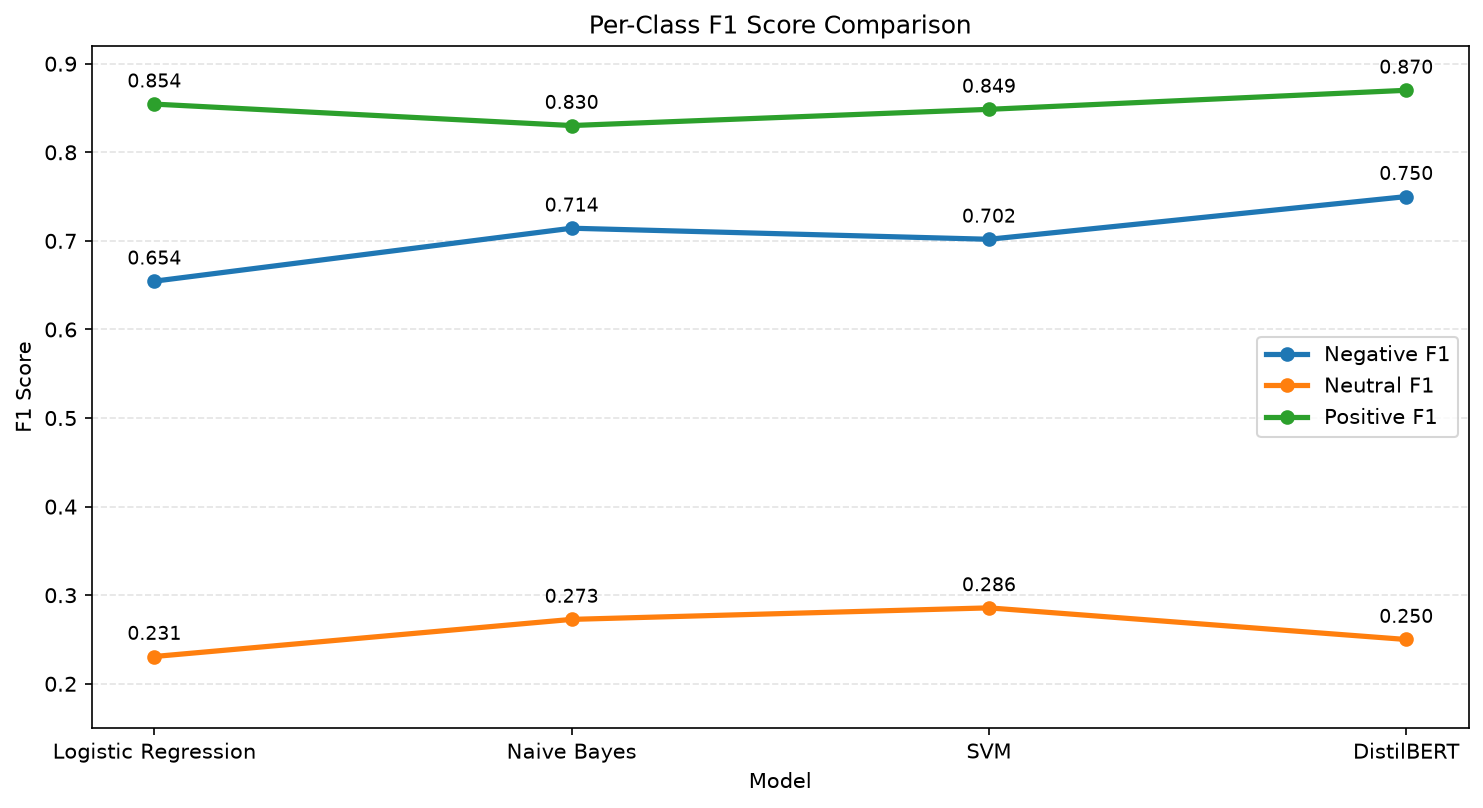

In [5]:
class_metrics = comparison_df.set_index("Model")[
    ["Negative F1", "Neutral F1", "Positive F1"]
]

fig, ax = plt.subplots(figsize=(10, 5.5))
x = range(len(class_metrics.index))

for metric in class_metrics.columns:
    values = class_metrics[metric].values
    ax.plot(x, values, marker="o", linewidth=2.5, label=metric)
    for xi, value in zip(x, values):
        ax.annotate(
            f"{value:.3f}",
            (xi, value),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9,
        )

ax.set_title("Per-Class F1 Score Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("F1 Score")
ax.set_xticks(list(x))
ax.set_xticklabels(class_metrics.index)
ax.set_ylim(0.15, 0.92)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(loc="center right")
plt.tight_layout()

save_path = OUTPUT_DIR / "F1_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {save_path}")


To compare the Precision and Recall to see how the model predicts conservatively (precision) and to observe whether the model captures more actual instances (recall)

Saved figure to: model_training\results\comparison\precision_recall.png


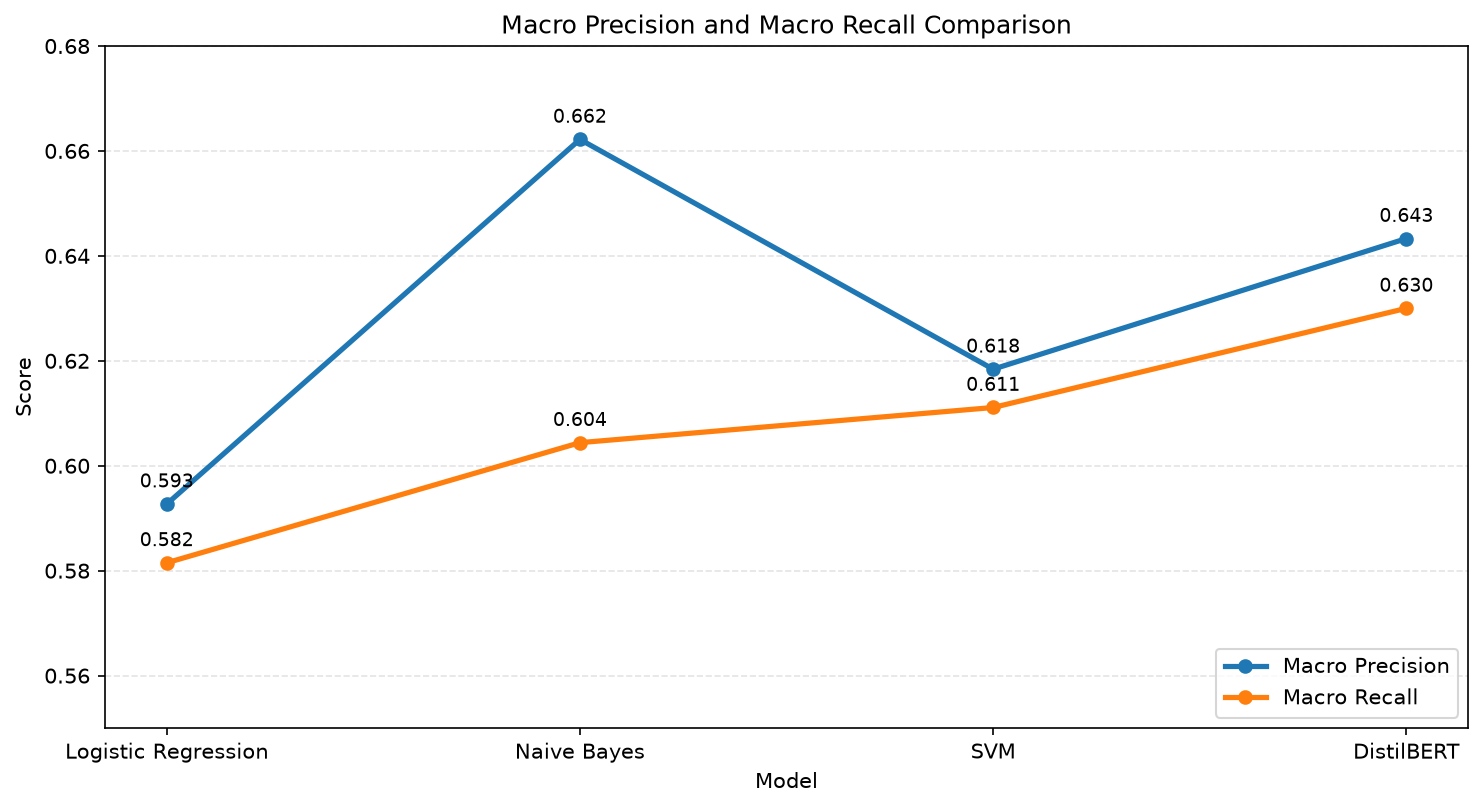

In [6]:
macro_metrics = comparison_df.set_index("Model")[
    ["Macro Precision", "Macro Recall"]
]

fig, ax = plt.subplots(figsize=(10, 5.5))
x = range(len(macro_metrics.index))

for metric in macro_metrics.columns:
    values = macro_metrics[metric].values
    ax.plot(x, values, marker="o", linewidth=2.5, label=metric)
    for xi, value in zip(x, values):
        ax.annotate(
            f"{value:.3f}",
            (xi, value),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9,
        )

ax.set_title("Macro Precision and Macro Recall Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_xticks(list(x))
ax.set_xticklabels(macro_metrics.index)
ax.set_ylim(0.55, 0.68)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(loc="lower right")
plt.tight_layout()

save_path = OUTPUT_DIR / "precision_recall.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {save_path}")
